In [1]:
import tensorflow as tf

import matplotlib.pyplot as plt

I0000 00:00:1782078305.873802    1157 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782078305.921085    1157 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782078307.447483    1157 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
DATASET_PATH = "/workspaces/plant_disease_detection/data/raw"

IMG_HEIGHT = 224

IMG_WIDTH = 224

BATCH_SIZE = 32

SEED = 42

In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    
    DATASET_PATH,

    validation_split=0.2,

    subset="training",

    seed=SEED,

    image_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


E0000 00:00:1782078309.450974    1157 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(

    DATASET_PATH,

    validation_split=0.2,

    subset="validation",

    seed=SEED,

    image_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [5]:
class_names = train_dataset.class_names

print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [6]:
NUM_CLASSES = len(class_names)

print("Number of Classes:", NUM_CLASSES)

Number of Classes: 15


In [8]:
for images, labels in train_dataset.take(1):

    print(images.shape)

    print(labels.shape)

(32, 224, 224, 3)
(32,)


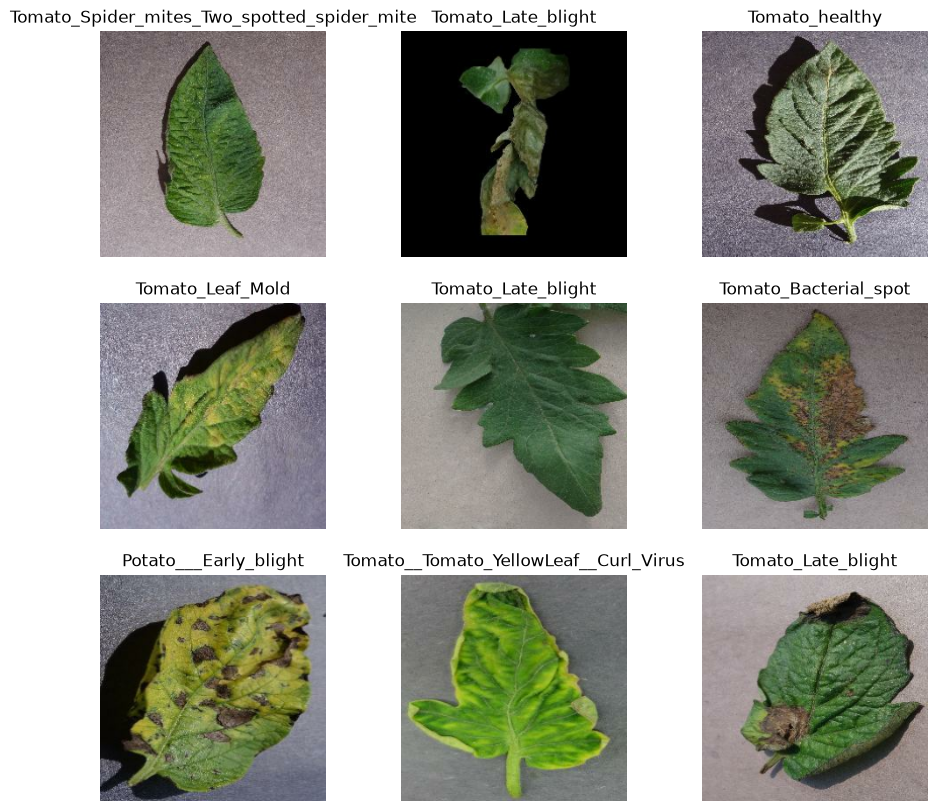

In [11]:
plt.figure(figsize=(11,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)